In [6]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

Fetching ... files: 0it [00:00, ?it/s]

Loaded data for 108 participants, activities: ['rest', 'walk', 'run', 'stairs']

Initializing Google TimesFM Foundation Model (v2.5)...

Extracting TimesFM Embeddings (Males Only, Hook Method)...
  Hooking into layer: 'output_projection_quantiles.residual_layer' Linear(in_features=1280, out_features=10240, bias=False)
Successfully extracted embeddings for 90/90 participants.
After removing smokers: 72 participants remaining.

Applying PCA + GMM (k=3)...

--- TimesFM GMM Cluster Evaluation ---
ARI : 0.0321
NMI : 0.0383
Accuracy (matched): 47.22%

              precision    recall  f1-score   support

      Normal       0.56      0.61      0.58        31
         Gym       0.40      0.19      0.26        21
      Sports       0.39      0.55      0.46        20

    accuracy                           0.47        72
   macro avg       0.45      0.45      0.43        72
weighted avg       0.47      0.47      0.45        72

             Pred Normal  Pred Gym  Pred Sports
True Normal        

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


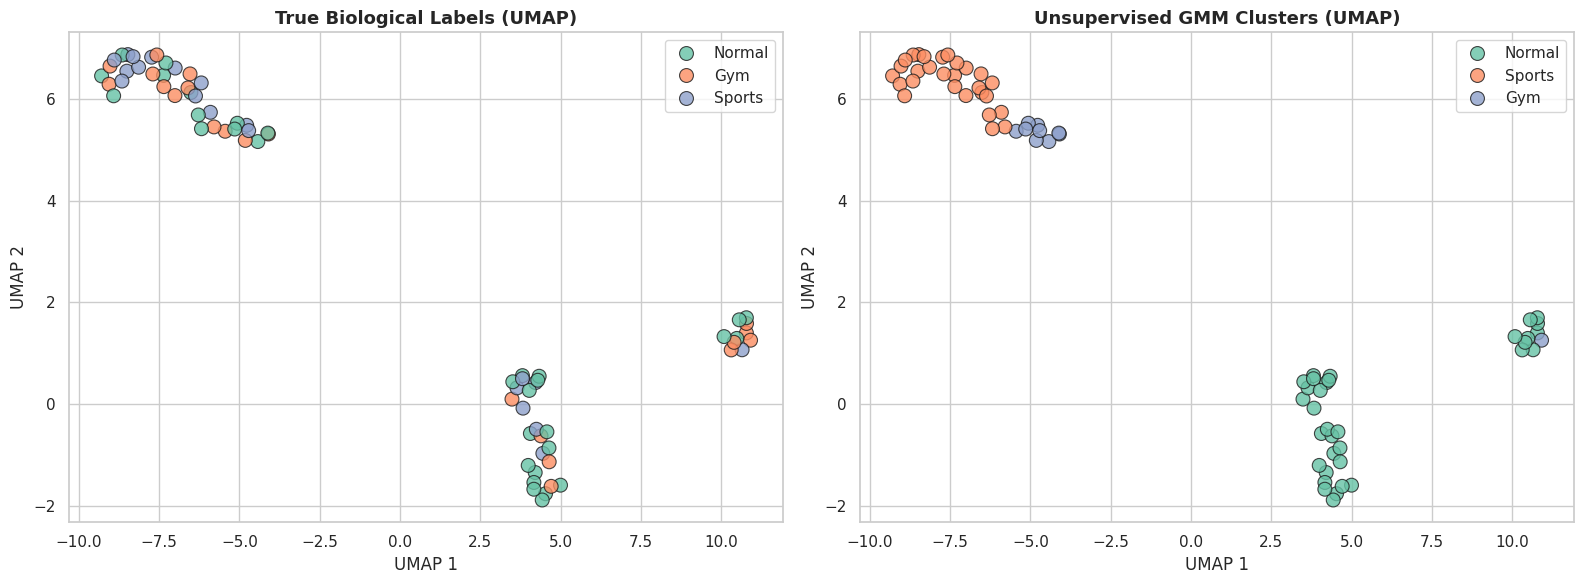

Saved: umap_gmm_clusters.png

Initializing Denoising Autoencoder...
  Epoch 50/200 | Loss: 0.0714
  Epoch 100/200 | Loss: 0.0877
  Epoch 150/200 | Loss: 0.1224
  Epoch 200/200 | Loss: 0.0630

--- Denoising AE + GMM Evaluation ---
ARI : 0.0343
NMI : 0.0418
Accuracy (matched): 47.22%

              precision    recall  f1-score   support

      Normal       0.58      0.61      0.59        31
         Gym       0.50      0.19      0.28        21
      Sports       0.35      0.55      0.43        20

    accuracy                           0.47        72
   macro avg       0.48      0.45      0.43        72
weighted avg       0.49      0.47      0.46        72


Running Supervised 5-Fold CV (Linear Head)...
  Fold 1/5...
  Fold 2/5...
  Fold 3/5...
  Fold 4/5...
  Fold 5/5...

SUPERVISED LINEAR HEAD ACCURACY: 38.89%

              precision    recall  f1-score   support

      Normal       0.44      0.45      0.44        31
         Gym       0.27      0.29      0.28        21
      Sports 

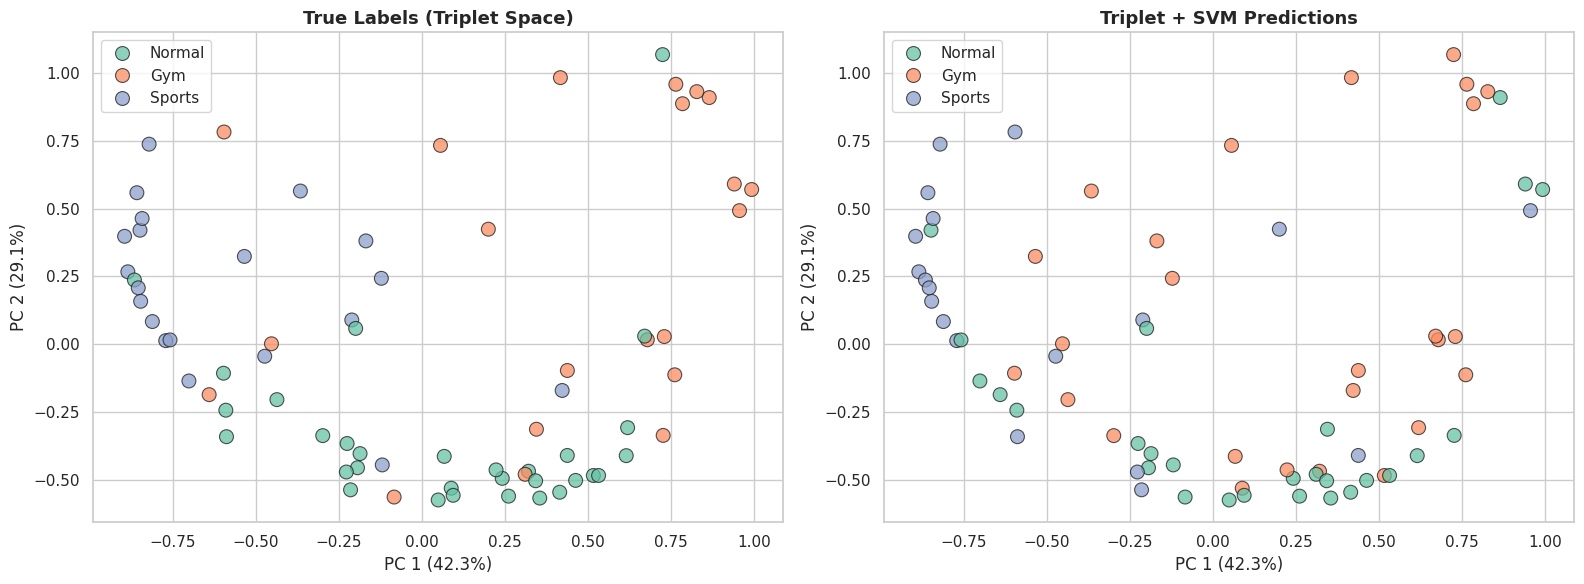

Saved: triplet_pca_clusters.png

Running DSP Delta Clustering (Run vs Rest)...
Delta features extracted for 72 participants.

--- DSP Delta Unsupervised Evaluation ---
ARI : 0.0162
Accuracy (matched): 44.44%

              precision    recall  f1-score   support

      Normal       0.45      0.81      0.57        31
         Gym       0.47      0.33      0.39        21
      Sports       0.00      0.00      0.00        20

    accuracy                           0.44        72
   macro avg       0.30      0.38      0.32        72
weighted avg       0.33      0.44      0.36        72


Generating balanced 60-participant waveform plots...


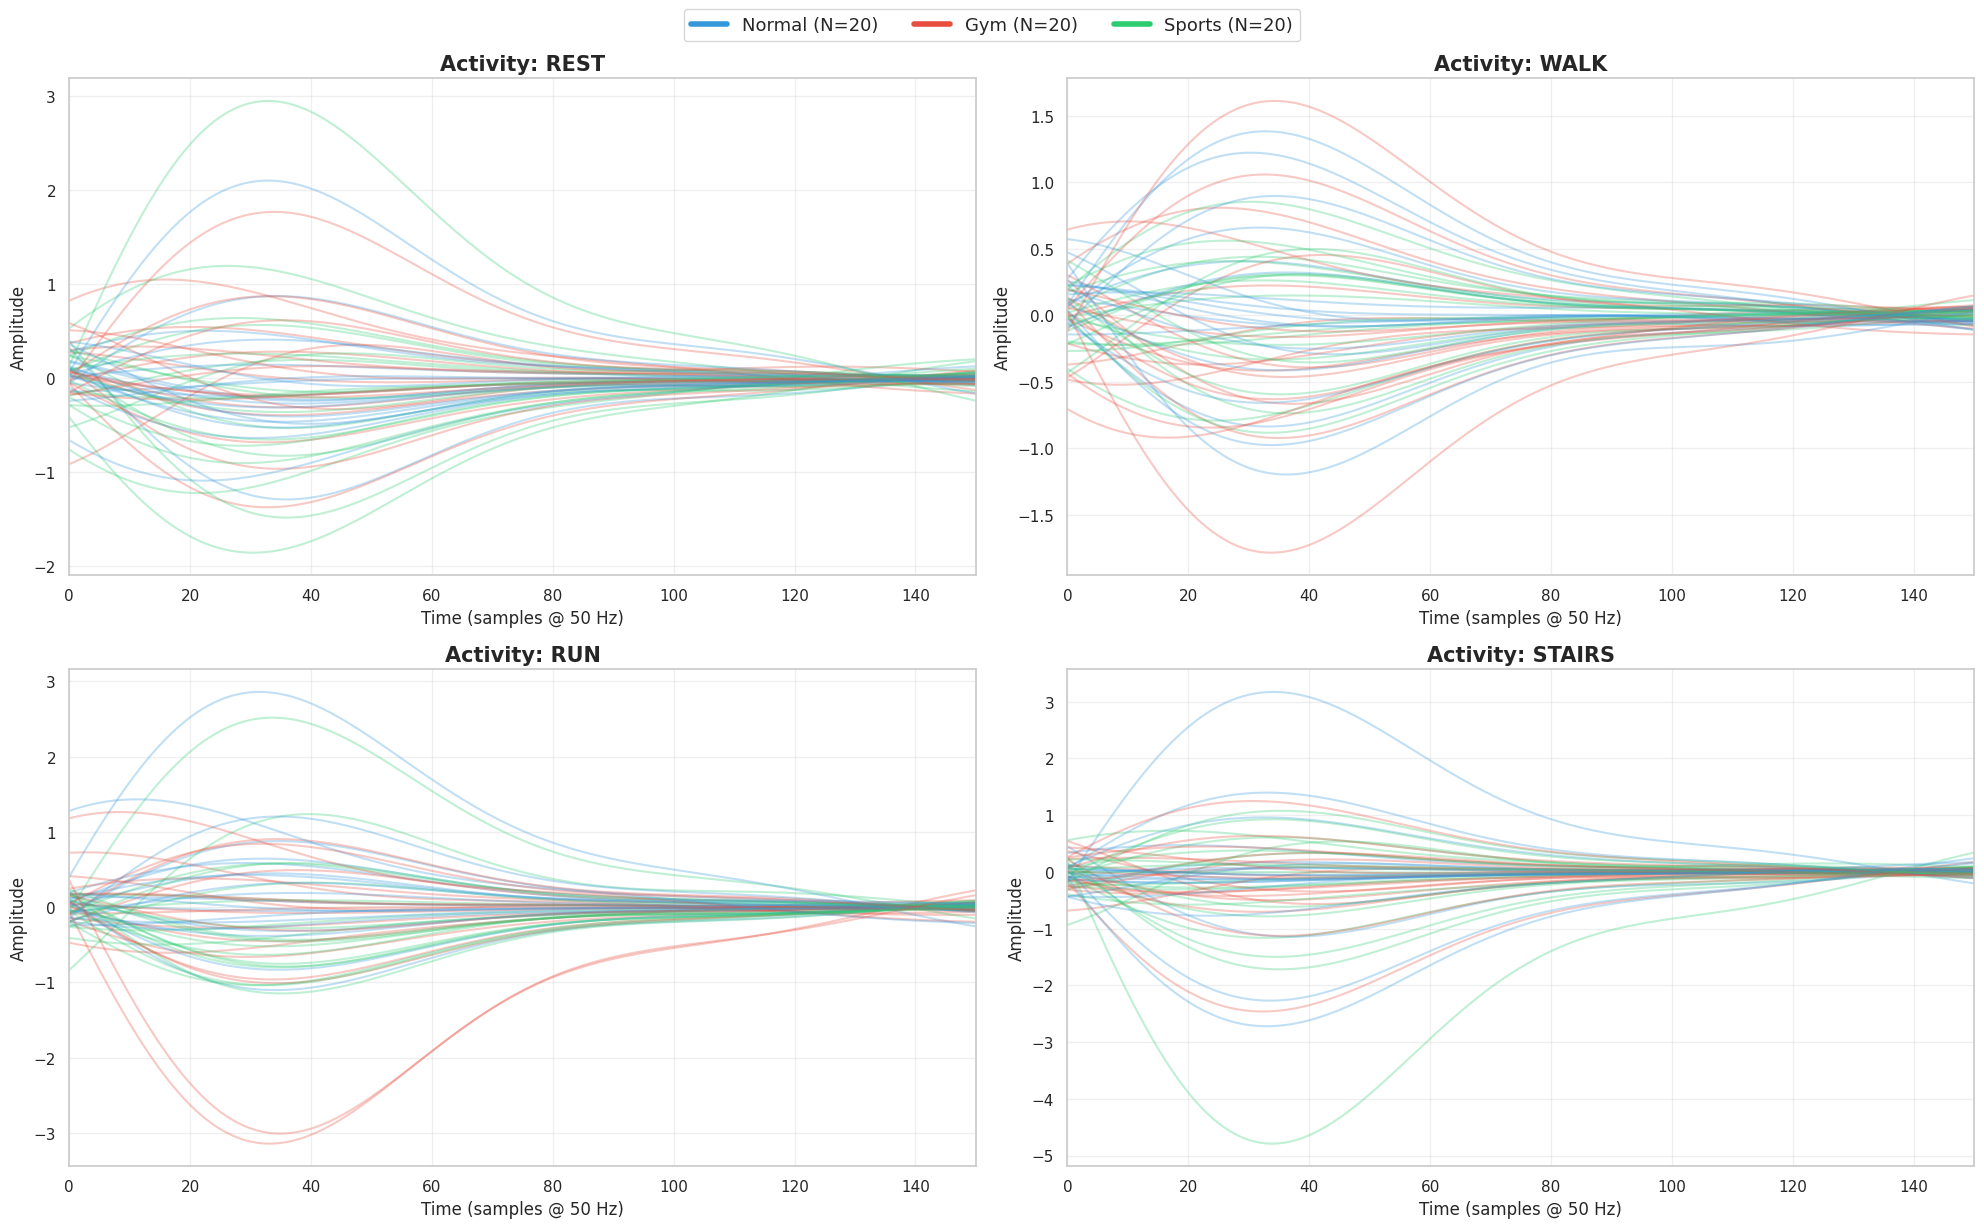

Saved: waveform_overlay.png

All done!


In [7]:


# ============================================================
# 0. INSTALL DEPENDENCIES (run once, then comment out)
# ============================================================
# !pip install -q "timesfm[torch]" huggingface_hub scikit-learn pandas numpy \
#              scipy torch matplotlib seaborn umap-learn --ignore-requires-python

# ============================================================
# 1. IMPORTS
# ============================================================
import os
import re
import glob
import ast
import random
import numpy as np
import pandas as pd
import torch
import timesfm
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.signal import butter, filtfilt, welch
from scipy.stats import skew, kurtosis, entropy
from scipy.optimize import linear_sum_assignment

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture
from sklearn.metrics import (
    adjusted_rand_score,
    normalized_mutual_info_score,
    confusion_matrix,
    classification_report,
    accuracy_score,
    davies_bouldin_score,
    calinski_harabasz_score,
)
from sklearn.model_selection import StratifiedKFold
from sklearn.svm import SVC

from torch import nn, optim
from torch.utils.data import Dataset, DataLoader, TensorDataset

from huggingface_hub import snapshot_download
from matplotlib.lines import Line2D

# ============================================================
# 2. DATA INGESTION
# ============================================================
print("Downloading BreathSense Dataset from Hugging Face...")
repo_path = snapshot_download(
    repo_id="BreathSense/BreathSense",
    repo_type="dataset",
    allow_patterns="data/**/*drmusic.csv",
)

all_files = glob.glob(f"{repo_path}/data/**/*drmusic.csv", recursive=True)
data_dict = {}

for file_path in all_files:
    activity = os.path.basename(os.path.dirname(file_path))
    match = re.search(r"(p\d+)", os.path.basename(file_path), re.IGNORECASE)
    if not match:
        continue
    person_id = match.group(1).lower()
    if person_id not in data_dict:
        data_dict[person_id] = {}
    data_dict[person_id][activity] = pd.read_csv(file_path).values.tolist()

final_df = pd.DataFrame.from_dict(data_dict, orient="index")
desired_columns = ["rest", "walk", "run", "stairs"]
existing_columns = [col for col in desired_columns if col in final_df.columns]
final_df = final_df[existing_columns]
final_df = final_df.loc[
    sorted(final_df.index, key=lambda x: int(x.replace("p", "")))
]
print(f"Loaded data for {len(final_df)} participants, activities: {existing_columns}")

# ============================================================
# 3. GROUND-TRUTH LABELS (defined early so all sections share them)
# ============================================================
gym_idx    = [x - 1 for x in [2, 5, 7, 10, 13, 20, 30, 33, 40, 44, 48, 50, 52, 63, 64, 68, 69, 79, 82, 86, 89]]
sports_idx = [x - 1 for x in [3, 6, 9, 11, 12, 22, 25, 37, 43, 49, 53, 54, 55, 65, 70, 76, 78, 81, 87, 88]]
smoker_idx = [x - 1 for x in [14, 15, 16, 17, 18, 19, 23, 27, 29, 32, 36, 42, 46, 60, 61, 62, 74, 75]]

all_males  = set(range(90))
normal_idx = list(all_males - set(gym_idx) - set(sports_idx) - set(smoker_idx))

y_true_all = np.zeros(90, dtype=int)
for pid in gym_idx:    y_true_all[pid] = 1
for pid in sports_idx: y_true_all[pid] = 2
# normal stays 0

# ============================================================
# 4. TIMESFM INITIALIZATION  (timesfm >= 2.0)
# ============================================================
print("\nInitializing Google TimesFM Foundation Model (v2.5)...")

# TimesFM 2.x replaced the old TimesFmHparams/TimesFmCheckpoint/TimesFm
# classes with model-specific constructors + a ForecastConfig.
# TimesFM_2p5_200M_torch uses the "google/timesfm-2.5-200m-pytorch" HF repo.
torch.set_float32_matmul_precision("high")   # speeds up matmul on modern GPUs/CPUs

tfm = timesfm.TimesFM_2p5_200M_torch.from_pretrained(
    "google/timesfm-2.5-200m-pytorch"
)

# ForecastConfig controls inference behaviour (no model weights are involved).
forecast_cfg = timesfm.ForecastConfig(
    max_context=512,
    max_horizon=32,
    normalize_inputs=True,
)
tfm.compile(forecast_cfg)

# ============================================================
# 5. DSP HELPERS
# ============================================================
def bandpass_filter(data, lowcut=0.1, highcut=0.6, fs=50.0, order=4):
    nyq = 0.5 * fs
    b, a = butter(order, [lowcut / nyq, highcut / nyq], btype="band")
    return filtfilt(b, a, data)


def safe_parse_signal(raw):
    """Convert raw cell value to a 1-D float numpy array, or return None."""
    if isinstance(raw, list):
        sig = np.array(raw)
    elif isinstance(raw, str):
        try:
            sig = np.array(ast.literal_eval(raw))
        except Exception:
            return None
    else:
        return None
    sig = np.ravel(sig).astype(float)
    return sig if len(sig) >= 50 else None


# ============================================================
# 6. TIMESFM EMBEDDING EXTRACTION (Hook Method, v2.x API)
# ============================================================
print("\nExtracting TimesFM Embeddings (Males Only, Hook Method)...")

activity_name = "run"
sampling_rate = 50

# In timesfm v2.x, TimesFM_2p5_200M_torch IS itself an nn.Module subclass,
# so we hook directly into it rather than hunting for a nested _model attr.
# Strategy: find the last nn.Linear in the entire model graph — this is the
# final output-projection layer whose *input* is the deep hidden state.
_pt_model = tfm   # tfm is directly the nn.Module in v2.x

# If tfm is not yet an nn.Module (some versions wrap lazily), fall back to scanning.
if not isinstance(_pt_model, nn.Module):
    _pt_model = None
    for attr in ("_model", "model", "_torch_model", "torch_model", "_backbone"):
        candidate = getattr(tfm, attr, None)
        if isinstance(candidate, nn.Module):
            _pt_model = candidate
            break
    if _pt_model is None:
        for attr in dir(tfm):
            try:
                candidate = getattr(tfm, attr)
                if isinstance(candidate, nn.Module):
                    _pt_model = candidate
                    break
            except Exception:
                pass
    if _pt_model is None:
        raise RuntimeError(
            "Could not locate an nn.Module inside the TimesFM object. "
            "Check your timesfm version."
        )

# Find the final Linear layer
linear_layers = [
    (name, module)
    for name, module in _pt_model.named_modules()
    if isinstance(module, nn.Linear)
]
if not linear_layers:
    raise RuntimeError("No nn.Linear layers found in the TimesFM model.")

final_proj_name, final_proj_layer = linear_layers[-1]
print(f"  Hooking into layer: '{final_proj_name}' {final_proj_layer}")

intercepted_embeddings = []

def _embedding_hook(module, inputs):
    """Captures the hidden state just before the final output projection."""
    hidden = inputs[0].detach().cpu().numpy()
    intercepted_embeddings.append(hidden)

hook_handle = final_proj_layer.register_forward_pre_hook(_embedding_hook)

# --- Run extraction ---
extracted_embeddings = []
valid_participants = []

for pid in range(90):
    raw = final_df.iloc[pid][activity_name]
    signal = safe_parse_signal(raw)
    if signal is None:
        continue

    clean = bandpass_filter(signal, fs=sampling_rate)

    # Tile if shorter than the required context
    if len(clean) < 512:
        repeats = (512 // len(clean)) + 2
        clean = np.tile(clean, repeats)

    context = clean[:512]
    intercepted_embeddings.clear()

    try:
        # v2.x API: forecast(horizon=..., inputs=[...])  — no freq argument
        tfm.forecast(horizon=32, inputs=[context])

        if not intercepted_embeddings:
            print(f"  pid {pid}: hook fired 0 times — skipping")
            continue

        raw_emb = intercepted_embeddings[0]          # e.g. (1, 16, 1280) or (16, 1280)
        d_model = raw_emb.shape[-1]
        person_emb = raw_emb.reshape(-1, d_model).mean(axis=0)   # → (d_model,)

        extracted_embeddings.append(person_emb)
        valid_participants.append(pid)
    except Exception as e:
        print(f"  pid {pid}: forecast error — {e}")

hook_handle.remove()   # always clean up, even on error

X_embeddings = np.vstack(extracted_embeddings)
print(f"Successfully extracted embeddings for {len(valid_participants)}/90 participants.")

# --- Filter out smokers ---
clean_indices, clean_y = [], []
for idx, pid in enumerate(valid_participants):
    if pid not in smoker_idx:
        clean_indices.append(idx)
        clean_y.append(y_true_all[pid])

X_embeddings_clean = X_embeddings[clean_indices]
y_true_filtered    = np.array(clean_y)
print(f"After removing smokers: {len(y_true_filtered)} participants remaining.")

# ============================================================
# 7. PCA + GMM CLUSTERING (k = 3)
# ============================================================
print("\nApplying PCA + GMM (k=3)...")

scaler_emb = StandardScaler()
X_scaled   = scaler_emb.fit_transform(X_embeddings_clean)

pca = PCA(n_components=10, random_state=42)
X_pca = pca.fit_transform(X_scaled)

gmm = GaussianMixture(n_components=3, covariance_type="full", random_state=42)
y_pred_gmm_raw = gmm.fit_predict(X_pca)

# --- Hungarian matching ---
def hungarian_match(y_true, y_pred, n_classes=3):
    cm = confusion_matrix(y_true, y_pred, labels=list(range(n_classes)))
    row_ind, col_ind = linear_sum_assignment(cm.max() - cm)
    mapping = {col: row for col, row in zip(col_ind, row_ind)}
    return np.array([mapping[label] for label in y_pred])

y_pred_gmm = hungarian_match(y_true_filtered, y_pred_gmm_raw)

target_names = ["Normal", "Gym", "Sports"]
print("\n--- TimesFM GMM Cluster Evaluation ---")
print(f"ARI : {adjusted_rand_score(y_true_filtered, y_pred_gmm_raw):.4f}")
print(f"NMI : {normalized_mutual_info_score(y_true_filtered, y_pred_gmm_raw):.4f}")
print(f"Accuracy (matched): {accuracy_score(y_true_filtered, y_pred_gmm) * 100:.2f}%\n")
print(classification_report(y_true_filtered, y_pred_gmm, target_names=target_names))
cm_df = pd.DataFrame(
    confusion_matrix(y_true_filtered, y_pred_gmm),
    index=[f"True {n}" for n in target_names],
    columns=[f"Pred {n}" for n in target_names],
)
print(cm_df)

# ============================================================
# 8. INTERNAL CLUSTERING METRICS
# ============================================================
print("\n--- Internal Clustering Metrics ---")
dbi = davies_bouldin_score(X_pca, y_pred_gmm_raw)
chi = calinski_harabasz_score(X_pca, y_pred_gmm_raw)
print(f"Davies-Bouldin Index (lower=better): {dbi:.4f}")
print(f"Calinski-Harabasz Index (higher=better): {chi:.4f}")

# ============================================================
# 9. UMAP VISUALISATION (GMM clusters)
# ============================================================
try:
    import umap

    print("\nGenerating 2D UMAP visualizations (GMM)...")
    reducer = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1, random_state=42)
    X_2d_umap = reducer.fit_transform(X_scaled)

    sns.set_theme(style="whitegrid")
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    label_map  = {0: "Normal", 1: "Gym", 2: "Sports"}
    true_strs  = [label_map[l] for l in y_true_filtered]
    pred_strs  = [label_map[l] for l in y_pred_gmm]

    for ax, labels, title in zip(
        axes,
        [true_strs, pred_strs],
        ["True Biological Labels (UMAP)", "Unsupervised GMM Clusters (UMAP)"],
    ):
        sns.scatterplot(
            ax=ax, x=X_2d_umap[:, 0], y=X_2d_umap[:, 1],
            hue=labels, palette="Set2", s=100, alpha=0.8, edgecolor="k",
        )
        ax.set_title(title, fontsize=13, fontweight="bold")
        ax.set_xlabel("UMAP 1"); ax.set_ylabel("UMAP 2")

    plt.tight_layout()
    plt.savefig("umap_gmm_clusters.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved: umap_gmm_clusters.png")

except ImportError:
    print("umap-learn not installed — skipping UMAP plot. Run: pip install umap-learn")

# ============================================================
# 10. DENOISING AUTOENCODER + GMM
# ============================================================
print("\nInitializing Denoising Autoencoder...")

torch.manual_seed(42)
np.random.seed(42)

X_tensor  = torch.tensor(X_embeddings_clean, dtype=torch.float32)
ae_loader = DataLoader(TensorDataset(X_tensor), batch_size=8, shuffle=True)


class DenoisingAE(nn.Module):
    def __init__(self, input_dim=1280, bottleneck=16):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 256), nn.BatchNorm1d(256), nn.GELU(), nn.Dropout(0.4),
            nn.Linear(256, bottleneck), nn.BatchNorm1d(bottleneck), nn.GELU(),
        )
        self.decoder = nn.Sequential(
            nn.Linear(bottleneck, 256), nn.BatchNorm1d(256), nn.GELU(), nn.Dropout(0.4),
            nn.Linear(256, input_dim),
        )

    def forward(self, x):
        z = self.encoder(x)
        return z, self.decoder(z)


ae_model   = DenoisingAE(input_dim=X_embeddings_clean.shape[1], bottleneck=16)
ae_optim   = optim.AdamW(ae_model.parameters(), lr=0.002, weight_decay=1e-3)
ae_loss_fn = nn.MSELoss()
noise_factor = 0.3

ae_model.train()
for epoch in range(200):
    ep_loss = 0.0
    for (batch,) in ae_loader:
        ae_optim.zero_grad()
        noisy = batch + noise_factor * torch.randn_like(batch)
        _, recon = ae_model(noisy)
        loss = ae_loss_fn(recon, batch)
        loss.backward(); ae_optim.step()
        ep_loss += loss.item()
    if (epoch + 1) % 50 == 0:
        print(f"  Epoch {epoch+1}/200 | Loss: {ep_loss / len(ae_loader):.4f}")

ae_model.eval()
with torch.no_grad():
    latent, _ = ae_model(X_tensor)
    latent = latent.numpy()

gmm_ae     = GaussianMixture(n_components=3, covariance_type="full", random_state=42)
y_pred_ae_raw = gmm_ae.fit_predict(latent)
y_pred_ae  = hungarian_match(y_true_filtered, y_pred_ae_raw)

print("\n--- Denoising AE + GMM Evaluation ---")
print(f"ARI : {adjusted_rand_score(y_true_filtered, y_pred_ae_raw):.4f}")
print(f"NMI : {normalized_mutual_info_score(y_true_filtered, y_pred_ae_raw):.4f}")
print(f"Accuracy (matched): {accuracy_score(y_true_filtered, y_pred_ae) * 100:.2f}%\n")
print(classification_report(y_true_filtered, y_pred_ae, target_names=target_names))

# ============================================================
# 11. SUPERVISED 5-FOLD CV (Linear Head)
# ============================================================
print("\nRunning Supervised 5-Fold CV (Linear Head)...")

torch.manual_seed(42)
np.random.seed(42)


class SupervisedHead(nn.Module):
    def __init__(self, input_dim=1280, num_classes=3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256), nn.BatchNorm1d(256), nn.ReLU(), nn.Dropout(0.4),
            nn.Linear(256, 64),  nn.BatchNorm1d(64),  nn.ReLU(),
            nn.Linear(64, num_classes),
        )

    def forward(self, x):
        return self.net(x)


skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
honest_preds_linear = np.zeros_like(y_true_filtered)

for fold, (train_idx, test_idx) in enumerate(
    skf.split(X_embeddings_clean, y_true_filtered), 1
):
    print(f"  Fold {fold}/5...")
    X_tr = torch.tensor(X_embeddings_clean[train_idx], dtype=torch.float32)
    X_te = torch.tensor(X_embeddings_clean[test_idx],  dtype=torch.float32)
    y_tr = torch.tensor(y_true_filtered[train_idx],    dtype=torch.long)

    head     = SupervisedHead(input_dim=X_embeddings_clean.shape[1])
    head_opt = optim.AdamW(head.parameters(), lr=0.001)
    ce_loss  = nn.CrossEntropyLoss()

    head.train()
    for _ in range(150):
        head_opt.zero_grad()
        loss = ce_loss(head(X_tr), y_tr)
        loss.backward(); head_opt.step()

    head.eval()
    with torch.no_grad():
        preds = head(X_te).argmax(dim=1).numpy()
    honest_preds_linear[test_idx] = preds

print(f"\n{'='*42}")
print(f"SUPERVISED LINEAR HEAD ACCURACY: {accuracy_score(y_true_filtered, honest_preds_linear)*100:.2f}%")
print(f"{'='*42}\n")
print(classification_report(y_true_filtered, honest_preds_linear, target_names=target_names))

# ============================================================
# 12. TRIPLET LOSS + SVM  (5-Fold CV)
# ============================================================
print("\nRunning Triplet Loss + SVM (5-Fold CV)...")

torch.manual_seed(42)
np.random.seed(42)


class TripletDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.labels = np.array(y)
        self.classes = np.unique(self.labels)
        self.class_idx = {c: np.where(self.labels == c)[0] for c in self.classes}

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        anchor = self.X[idx]
        a_lbl  = self.labels[idx]

        pos_idx = idx
        while pos_idx == idx:
            pos_idx = np.random.choice(self.class_idx[a_lbl])
        positive = self.X[pos_idx]

        neg_lbl = np.random.choice([c for c in self.classes if c != a_lbl])
        negative = self.X[np.random.choice(self.class_idx[neg_lbl])]

        return anchor, positive, negative


class TripletProjector(nn.Module):
    def __init__(self, input_dim=1280, out_dim=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256), nn.BatchNorm1d(256), nn.GELU(), nn.Dropout(0.3),
            nn.Linear(256, out_dim),
        )

    def forward(self, x):
        return nn.functional.normalize(self.net(x), p=2, dim=1)


honest_preds_triplet = np.zeros_like(y_true_filtered)
triplet_model = None  # will hold the last trained model for visualization

for fold, (train_idx, test_idx) in enumerate(
    skf.split(X_embeddings_clean, y_true_filtered), 1
):
    print(f"  Fold {fold}/5...")
    X_tr, X_te = X_embeddings_clean[train_idx], X_embeddings_clean[test_idx]
    y_tr, y_te = y_true_filtered[train_idx], y_true_filtered[test_idx]

    sc = StandardScaler()
    X_tr_s = sc.fit_transform(X_tr)
    X_te_s  = sc.transform(X_te)

    ds     = TripletDataset(X_tr_s, y_tr)
    loader = DataLoader(ds, batch_size=16, shuffle=True)

    proj     = TripletProjector(input_dim=X_embeddings_clean.shape[1], out_dim=64)
    t_opt    = optim.AdamW(proj.parameters(), lr=0.001, weight_decay=1e-4)
    t_loss   = nn.TripletMarginLoss(margin=1.0, p=2)

    proj.train()
    for _ in range(100):
        for a, p, n in loader:
            t_opt.zero_grad()
            loss = t_loss(proj(a), proj(p), proj(n))
            loss.backward(); t_opt.step()

    proj.eval()
    with torch.no_grad():
        X_tr_proj = proj(torch.tensor(X_tr_s, dtype=torch.float32)).numpy()
        X_te_proj = proj(torch.tensor(X_te_s, dtype=torch.float32)).numpy()

    svm = SVC(kernel="linear", C=1.0, random_state=42)
    svm.fit(X_tr_proj, y_tr)
    honest_preds_triplet[test_idx] = svm.predict(X_te_proj)
    triplet_model = proj   # keep last model for viz

print(f"\n{'='*42}")
print(f"TRIPLET LOSS + SVM ACCURACY: {accuracy_score(y_true_filtered, honest_preds_triplet)*100:.2f}%")
print(f"{'='*42}\n")
print(classification_report(y_true_filtered, honest_preds_triplet, target_names=target_names))

# ============================================================
# 13. TRIPLET LOSS VISUALISATION (PCA of projected space)
# ============================================================
print("\nGenerating Triplet Loss visualizations...")

sc_full = StandardScaler()
X_full_s = sc_full.fit_transform(X_embeddings_clean)

triplet_model.eval()
with torch.no_grad():
    X_proj_64 = triplet_model(torch.tensor(X_full_s, dtype=torch.float32)).numpy()

pca_2d = PCA(n_components=2, random_state=42)
X_2d_pca = pca_2d.fit_transform(X_proj_64)
var = pca_2d.explained_variance_ratio_
print(f"Variance explained in 2D: {sum(var)*100:.2f}%")

label_map = {0: "Normal", 1: "Gym", 2: "Sports"}
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, lbls, title in zip(
    axes,
    [y_true_filtered, honest_preds_triplet],
    ["True Labels (Triplet Space)", "Triplet + SVM Predictions"],
):
    sns.scatterplot(
        ax=ax, x=X_2d_pca[:, 0], y=X_2d_pca[:, 1],
        hue=[label_map[l] for l in lbls],
        palette="Set2", s=100, alpha=0.75, edgecolor="k",
    )
    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.set_xlabel(f"PC 1 ({var[0]*100:.1f}%)")
    ax.set_ylabel(f"PC 2 ({var[1]*100:.1f}%)")

plt.tight_layout()
plt.savefig("triplet_pca_clusters.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: triplet_pca_clusters.png")

# ============================================================
# 14. DSP DELTA FEATURES (Unsupervised, no TimesFM)
# ============================================================
print("\nRunning DSP Delta Clustering (Run vs Rest)...")


def calc_dsp_features(signal, fs=50.0):
    freqs, psd = welch(signal, fs=fs, nperseg=max(len(signal) // 2, 4))
    valid = (freqs >= 0.1) & (freqs <= 0.6)
    dom_freq = freqs[valid][np.argmax(psd[valid])] if valid.any() else 0.0
    psd_norm = psd[valid] / (psd[valid].sum() + 1e-12) if valid.any() else np.array([1.0])
    return np.array([np.std(signal), skew(signal), kurtosis(signal), dom_freq, entropy(psd_norm)])


class_map = {pid: 0 for pid in normal_idx}
class_map.update({pid: 1 for pid in gym_idx})
class_map.update({pid: 2 for pid in sports_idx})

X_delta, y_delta, valid_delta_pids = [], [], []

for pid in range(90):
    if pid in smoker_idx:
        continue
    rest_sig = safe_parse_signal(final_df.iloc[pid]["rest"])
    run_sig  = safe_parse_signal(final_df.iloc[pid]["run"])
    if rest_sig is None or run_sig is None:
        continue

    rest_clean = bandpass_filter(rest_sig)
    run_clean  = bandpass_filter(run_sig)

    # Tile to stabilize FFT
    for arr in [rest_clean, run_clean]:
        if len(arr) < 500:
            arr = np.tile(arr, (500 // len(arr)) + 1)

    X_delta.append(calc_dsp_features(run_clean) - calc_dsp_features(rest_clean))
    y_delta.append(class_map[pid])
    valid_delta_pids.append(pid)

X_delta = np.array(X_delta)
y_delta = np.array(y_delta)
print(f"Delta features extracted for {len(valid_delta_pids)} participants.")

sc_delta = StandardScaler()
X_delta_s = sc_delta.fit_transform(X_delta)

pca_d = PCA(n_components=3, random_state=42)
X_delta_pca = pca_d.fit_transform(X_delta_s)

gmm_delta = GaussianMixture(n_components=3, covariance_type="full", random_state=42)
y_delta_raw = gmm_delta.fit_predict(X_delta_pca)
y_delta_matched = hungarian_match(y_delta, y_delta_raw)

print("\n--- DSP Delta Unsupervised Evaluation ---")
print(f"ARI : {adjusted_rand_score(y_delta, y_delta_raw):.4f}")
print(f"Accuracy (matched): {accuracy_score(y_delta, y_delta_matched)*100:.2f}%\n")
print(classification_report(y_delta, y_delta_matched, target_names=target_names))

# ============================================================
# 15. WAVEFORM OVERLAY PLOTS (all activities, balanced 60)
# ============================================================
print("\nGenerating balanced 60-participant waveform plots...")

random.seed(42)
balanced_normal = random.sample(normal_idx, 20)
balanced_gym    = random.sample(gym_idx, 20)
balanced_sports = list(sports_idx)[:20]
allowed_pids    = set(balanced_normal + balanced_gym + balanced_sports)


def get_color(pid):
    if pid in gym_idx:    return "#e74c3c"
    if pid in sports_idx: return "#2ecc71"
    return "#3498db"


activities = [c for c in ["rest", "walk", "run", "stairs"] if c in final_df.columns]
fig, axes  = plt.subplots(
    (len(activities) + 1) // 2, 2, figsize=(20, 12)
)
axes = axes.flatten()

for i, act in enumerate(activities):
    ax = axes[i]
    ax.set_title(f"Activity: {act.upper()}", fontsize=15, fontweight="bold")

    for pid in range(len(final_df)):
        if pid not in allowed_pids:
            continue
        sig = safe_parse_signal(final_df.iloc[pid][act])
        if sig is None:
            continue
        clean = bandpass_filter(sig)
        ax.plot(clean[:300], color=get_color(pid), alpha=0.3, linewidth=1.5)

    ax.set_xlabel("Time (samples @ 50 Hz)")
    ax.set_ylabel("Amplitude")
    ax.set_xlim(0, 150)
    ax.grid(True, alpha=0.3)

# Hide any unused subplots
for j in range(len(activities), len(axes)):
    axes[j].set_visible(False)

legend_elements = [
    Line2D([0], [0], color="#3498db", lw=4, label="Normal (N=20)"),
    Line2D([0], [0], color="#e74c3c", lw=4, label="Gym (N=20)"),
    Line2D([0], [0], color="#2ecc71", lw=4, label="Sports (N=20)"),
]
fig.legend(handles=legend_elements, loc="upper center", ncol=3,
           fontsize=13, bbox_to_anchor=(0.5, 1.03))
plt.tight_layout()
plt.savefig("waveform_overlay.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: waveform_overlay.png")

print("\nAll done!")